# Lab 6 (Step 3): Outdoor polluted data vs Outdoor standard

This notebook compares outdoor data collected at a 'worse quality' to our control outdoor data

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from pathlib import Path

# new data path ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
cwd = Path.cwd()
outcontrolpath = cwd / "datafolder" / "rundata.csv"
outpolpath = cwd / "datafolder" / "outdoor1.csv"
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


# mask
outdoorc = pd.read_csv(outcontrolpath)
outdoorp = pd.read_csv(outpolpath)

# now apply the masks once
outdoorc = outdoorc[outdoorc["Timestamp"] > 1771634650].copy()
outdoorp = outdoorp[outdoorp["Timestamp"] > 1772235454].copy()    


PAIR_MAP = {
    "Temperature": "Temp",
    "Humidity": "Humidity",
    "Pressure": "Pressure",
    "2.5": "PM25_Env",
}

T_END = 300  # seconds

def prepare_df(df, time_col, keep_cols, t_end=T_END, gap_threshold=30):
    
    df = df.copy()

    cols = [time_col] + [c for c in keep_cols if c in df.columns]
    df = df[cols]

    # Convert time to numeric (seconds-like) and drop non-numeric rows
    t = pd.to_numeric(df[time_col], errors="coerce")
    df = df.assign(t_raw=t).dropna(subset=["t_raw"]).copy()

    # Sort by time
    df = df.sort_values("t_raw").reset_index(drop=True)

    # Choose a robust t0
    t_raw = df["t_raw"].to_numpy()
    if len(t_raw) >= 2:
        dt = np.diff(t_raw)
        # Find the first large gap
        large_gap_idx = np.where(dt > gap_threshold)[0]
        if large_gap_idx.size > 0:
            j = int(large_gap_idx[0] + 1)  # first index after the gap
            # Only apply if the gap is near the beginning (likely a stray startup record)
            if j <= max(5, int(0.1 * len(df))):
                df = df.iloc[j:].reset_index(drop=True)
                t_raw = df["t_raw"].to_numpy()

    t0 = float(t_raw[0]) if len(t_raw) else np.nan
    df["t_sec"] = df["t_raw"] - t0

    # Coerce required data columns to numeric
    for c in keep_cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    # Trim to [0, t_end]
    df = df[(df["t_sec"] >= 0) & (df["t_sec"] <= t_end)].copy()
    return df

def drop_first_seconds_and_rezero(df, seconds, t_end=T_END):
    """Drop the first `seconds` of data (by t_sec) and re-zero time so plots run 0..t_end."""
    if seconds is None or seconds <= 0 or len(df) == 0:
        return df
    df = df[df["t_sec"] >= seconds].copy()
    df["t_sec"] = df["t_sec"] - seconds
    df = df[(df["t_sec"] >= 0) & (df["t_sec"] <= t_end)].copy()
    return df

def stats_table(x_a, x_b, label_a, label_b):
    x_a = np.asarray(x_a, dtype=float)
    x_b = np.asarray(x_b, dtype=float)
    x_a = x_a[np.isfinite(x_a)]
    x_b = x_b[np.isfinite(x_b)]

    def _stats(x):
        if len(x) == 0:
            return {"N": 0, "Mean": np.nan, "Std": np.nan, "Min": np.nan, "Max": np.nan}
        return {"N": len(x), "Mean": np.mean(x), "Std": np.std(x, ddof=1) if len(x) > 1 else 0.0,
                "Min": np.min(x), "Max": np.max(x)}

    a = _stats(x_a); b = _stats(x_b)
#     return pd.DataFrame([a, b], index=[label_a, label_b])  # removed per request


def stats_and_test(x_a, x_b):
    """Return a dict of descriptive stats + how many sigma apart the means are."""
    x_a = pd.to_numeric(pd.Series(x_a), errors="coerce").to_numpy(dtype=float)
    x_b = pd.to_numeric(pd.Series(x_b), errors="coerce").to_numpy(dtype=float)

    x_a = x_a[np.isfinite(x_a)]
    x_b = x_b[np.isfinite(x_b)]

    n_a, n_b = len(x_a), len(x_b)
    mean_a = np.mean(x_a) if n_a else np.nan
    mean_b = np.mean(x_b) if n_b else np.nan

    sigma_a = np.std(x_a, ddof=1) if n_a > 1 else np.nan
    sigma_b = np.std(x_b, ddof=1) if n_b > 1 else np.nan

    sigma_mean_a = sigma_a / np.sqrt(n_a) if n_a > 1 else np.nan
    sigma_mean_b = sigma_b / np.sqrt(n_b) if n_b > 1 else np.nan

    sigma_diff = np.sqrt(sigma_mean_a**2 + sigma_mean_b**2) if np.isfinite(sigma_mean_a) and np.isfinite(sigma_mean_b) else np.nan
    diff = abs(mean_a - mean_b) if np.isfinite(mean_a) and np.isfinite(mean_b) else np.nan
    n_sigma = (diff / sigma_diff) if np.isfinite(diff) and np.isfinite(sigma_diff) and sigma_diff != 0 else np.nan

    return {
        "n_a": n_a, "n_b": n_b,
        "mean_a": mean_a, "mean_b": mean_b,
        "sigma_a": sigma_a, "sigma_b": sigma_b,
        "sigma_mean_a": sigma_mean_a, "sigma_mean_b": sigma_mean_b,
        "diff": diff, "sigma_diff": sigma_diff,
        "n_sigma": n_sigma,
        "different_3sigma": bool(np.isfinite(n_sigma) and n_sigma > 3.0),
    }

def compare_one_variable(df_a, df_b, col_a, col_b, label_a, label_b, env_label, var_label):
    """Plot time series + histogram for one variable (Control vs Polluted)."""
    # Time series
    plt.figure()
    plt.plot(df_a["t_sec"], df_a[col_a], label=label_a)
    plt.plot(df_b["t_sec"], df_b[col_b], label=label_b)
    plt.xlim(0, T_END)
    plt.xlabel("Time (s)")
    plt.ylabel(var_label)
    plt.title(f"Control vs Polluted {env_label} {var_label} (Time Series)")
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()

    # Histogram
    plt.figure()
    plt.hist(df_a[col_a].dropna(), bins=30, alpha=0.6, label=label_a)
    plt.hist(df_b[col_b].dropna(), bins=30, alpha=0.6, label=label_b)
    plt.xlabel(var_label)
    plt.ylabel("Count")
    plt.title(f"Control vs Polluted {env_label} {var_label} (Histogram)")
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()
    # Summary stats table
#     display(stats_table(df_a[col_a], df_b[col_b], label_a, label_b))  # removed per request

    # Full stats + sigma separation (matches the other notebook)
    s = stats_and_test(df_a[col_a], df_b[col_b])
    print(f"--- {env_label} {var_label} ---")
    print(f"N {label_a} = {s['n_a']}, N {label_b} = {s['n_b']}")
    print(f"Mean {label_a}  = {s['mean_a']:.6g}")
    print(f"Mean {label_b} = {s['mean_b']:.6g}")
    print(f"Sigma (intrinsic) {label_a}  = {s['sigma_a']:.6g}")
    print(f"Sigma (intrinsic) {label_b} = {s['sigma_b']:.6g}")
    print(f"Sigma_mean {label_a}  = {s['sigma_mean_a']:.6g}")
    print(f"Sigma_mean {label_b} = {s['sigma_mean_b']:.6g}")
    print(f"|Δmean| = {s['diff']:.6g}")
    print(f"Combined sigma_mean (for Δ) = {s['sigma_diff']:.6g}")
    print(f"Separation (|Δmean| / σΔmean) = {s['n_sigma']:.6g} σ")
    if s["different_3sigma"]:
        print("Statistically different at > 3σ")
    else:
        print("Not statistically different at > 3σ")
# -----------------------------
# Prepare datasets
# -----------------------------
our_outdoorc   = prepare_df(outdoorc,     time_col="Timestamp", keep_cols=list(PAIR_MAP.values()))

our_outdoorp   = prepare_df(outdoorp,    time_col="Timestamp", keep_cols=list(PAIR_MAP.values()))


# Mask off first 30 seconds for OUTDOOR comparison (from each dataset), then re-zero time to start at 0s
our_outdoor   = drop_first_seconds_and_rezero(our_outdoorp,   30)

LABEL_OUR_OUTDOORC   = "Our Group Outdoor Control"
LABEL_OUR_OUTDOORP  = "Our Group Outdoor Polluted"



## Outdoor comparisons (Control vs Polluted)

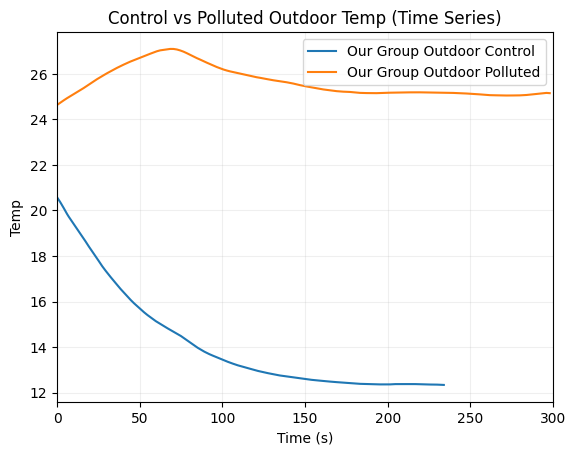

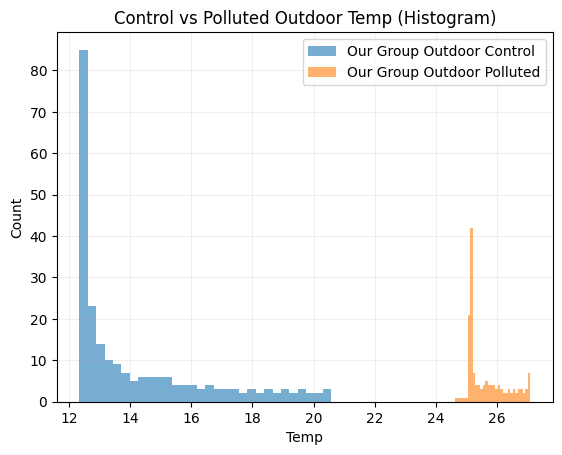

--- Outdoor Temp ---
N Our Group Outdoor Control = 232, N Our Group Outdoor Polluted = 149
Mean Our Group Outdoor Control  = 14.1497
Mean Our Group Outdoor Polluted = 25.6441
Sigma (intrinsic) Our Group Outdoor Control  = 2.258
Sigma (intrinsic) Our Group Outdoor Polluted = 0.654739
Sigma_mean Our Group Outdoor Control  = 0.148245
Sigma_mean Our Group Outdoor Polluted = 0.0536383
|Δmean| = 11.4944
Combined sigma_mean (for Δ) = 0.157651
Separation (|Δmean| / σΔmean) = 72.9109 σ
Statistically different at > 3σ


In [44]:
# Outdoor: Temp
compare_one_variable(
    df_a=our_outdoorc,
    df_b=our_outdoorp,
    col_a="Temp",
    col_b="Temp",
    label_a="Our Group Outdoor Control",
    label_b="Our Group Outdoor Polluted",
    env_label="Outdoor",
    var_label="Temp",
)

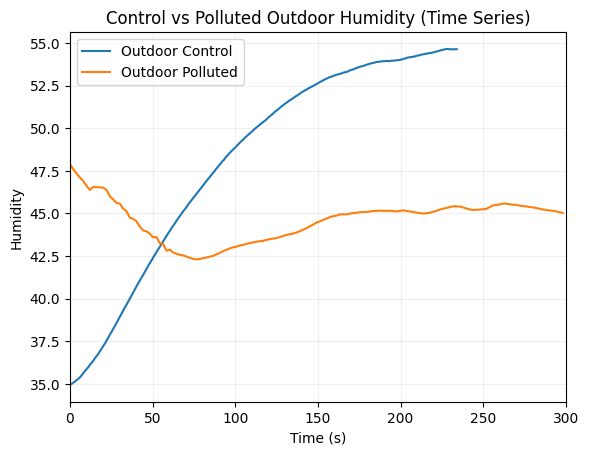

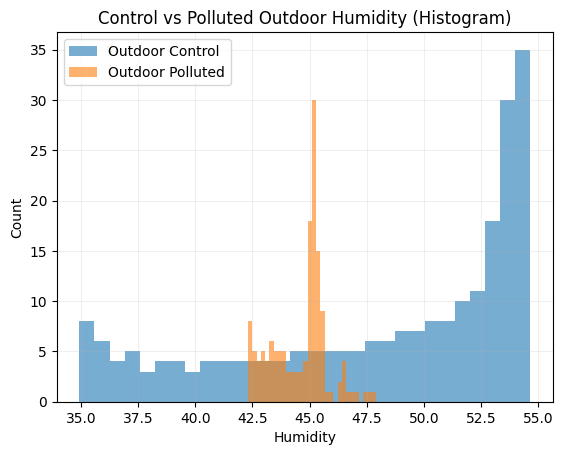

--- Outdoor Humidity ---
N Outdoor Control = 232, N Outdoor Polluted = 149
Mean Outdoor Control  = 48.1725
Mean Outdoor Polluted = 44.6193
Sigma (intrinsic) Outdoor Control  = 6.18282
Sigma (intrinsic) Outdoor Polluted = 1.21432
Sigma_mean Outdoor Control  = 0.405922
Sigma_mean Outdoor Polluted = 0.099481
|Δmean| = 3.55312
Combined sigma_mean (for Δ) = 0.417934
Separation (|Δmean| / σΔmean) = 8.50162 σ
Statistically different at > 3σ


In [45]:
# Outdoor: Humidity
compare_one_variable(
    df_a=our_outdoorc,
    df_b=our_outdoorp,
    col_a="Humidity",
    col_b="Humidity",
    label_a="Outdoor Control",
    label_b="Outdoor Polluted",
    env_label="Outdoor",
    var_label="Humidity",
)


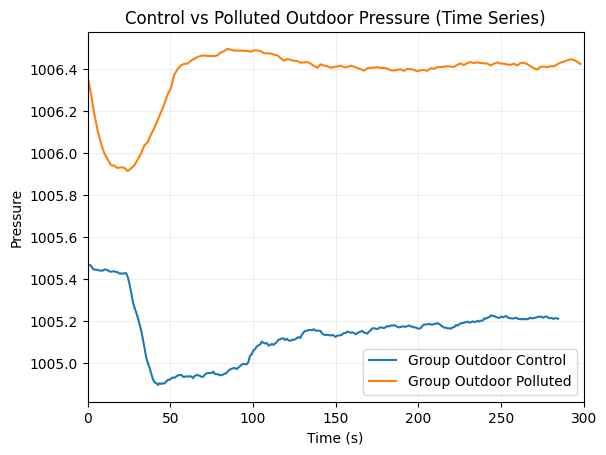

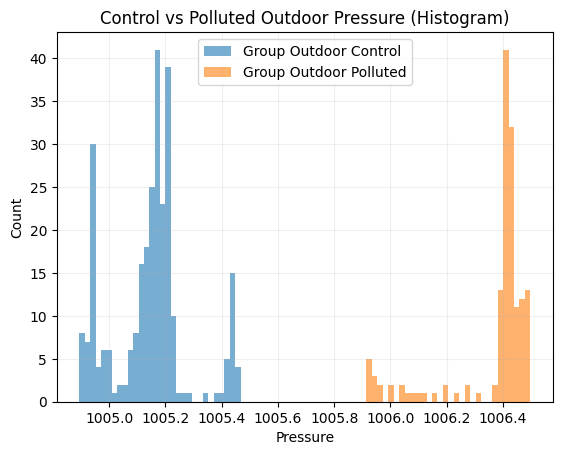

--- Outdoor Pressure ---
N Group Outdoor Control = 282, N Group Outdoor Polluted = 149
Mean Group Outdoor Control  = 1005.14
Mean Group Outdoor Polluted = 1006.37
Sigma (intrinsic) Group Outdoor Control  = 0.136167
Sigma (intrinsic) Group Outdoor Polluted = 0.150479
Sigma_mean Group Outdoor Control  = 0.00810861
Sigma_mean Group Outdoor Polluted = 0.0123277
|Δmean| = 1.22416
Combined sigma_mean (for Δ) = 0.0147554
Separation (|Δmean| / σΔmean) = 82.9634 σ
Statistically different at > 3σ


In [41]:
# Outdoor: Pressure
compare_one_variable(
    df_a=our_outdoorc,
    df_b=our_outdoorp,
    col_a="Pressure",
    col_b="Pressure",
    label_a="Group Outdoor Control",
    label_b="Group Outdoor Polluted",
    env_label="Outdoor",
    var_label="Pressure",
)


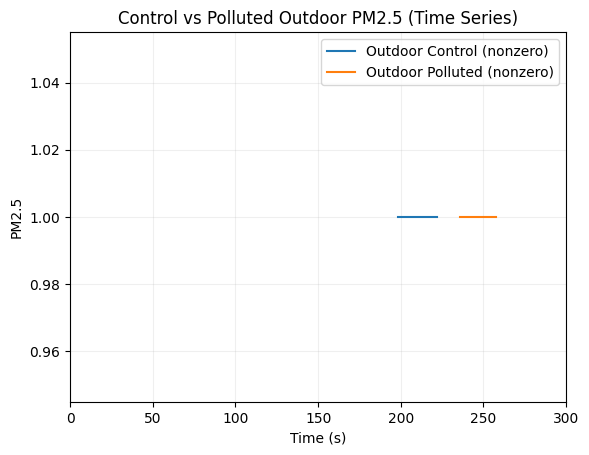

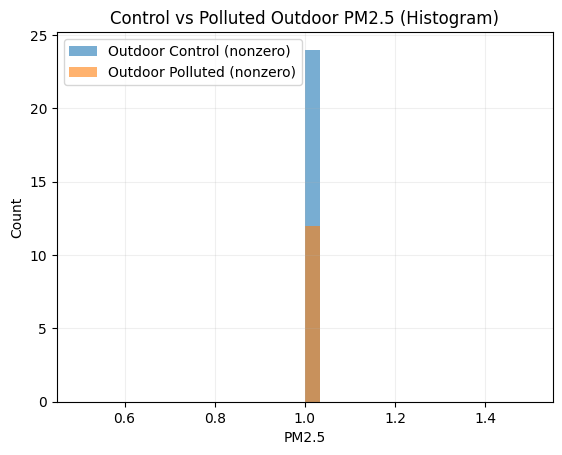

--- Outdoor PM2.5 ---
N Outdoor Control (nonzero) = 24, N Outdoor Polluted (nonzero) = 12
Mean Outdoor Control (nonzero)  = 1
Mean Outdoor Polluted (nonzero) = 1
Sigma (intrinsic) Outdoor Control (nonzero)  = 0
Sigma (intrinsic) Outdoor Polluted (nonzero) = 0
Sigma_mean Outdoor Control (nonzero)  = 0
Sigma_mean Outdoor Polluted (nonzero) = 0
|Δmean| = 0
Combined sigma_mean (for Δ) = 0
Separation (|Δmean| / σΔmean) = nan σ
Not statistically different at > 3σ


In [46]:
# Outdoor: PM2.5 (drops zeros before plotting)
# filter out the 0 values so the plot focuses on non-zero readings, as the 0 values are just the sensor's lower limit and not meaningful for comparison
our_outdoorc_nz = our_outdoorc[our_outdoorc["PM25_Env"] != 0].copy()
our_outdoorp_nz = our_outdoorp[our_outdoorp["PM25_Env"] != 0].copy()

compare_one_variable(
    df_a=our_outdoorc_nz,
    df_b=our_outdoorp_nz,
    col_a="PM25_Env",
    col_b="PM25_Env",
    label_a="Outdoor Control (nonzero)",
    label_b="Outdoor Polluted (nonzero)",
    env_label="Outdoor",
    var_label="PM2.5",
)